In [ ]:
# 1. Setup: imports & installs (Colab-safe)
!pip -q install wordcloud==1.9.3

import os, zipfile, glob, itertools, io, json, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from wordcloud import WordCloud

plt.rcParams['figure.figsize'] = (7,4)
print("Imports ready, TensorFlow version:", tf.__version__)

# Optional: reduce TF logging noise
import logging, warnings
warnings.filterwarnings("ignore")
logging.getLogger("tensorflow").setLevel(logging.ERROR)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.6/541.6 kB 9.7 MB/s eta 0:00:00
Imports ready, TensorFlow version: 2.19.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
print(os.listdir("/content/drive/MyDrive"))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['Colab Notebooks', 'certificates', 'IMG_20170930_180354.jpg', 'IMG_1789.jpg', 'K.Varun Kumar-Resume.pdf', '2. ISP 10 Seminar presentation for ISPs (tej).pptx', '2.xps', '1.xps', 'ISP 10 - Completion certificate', '2. ISP 10 Seminar presentation for ISPs (tej).gslides', 'masters in germany.teja.docx', 'cambridgeielts10.pdf', 'basic codeing', 'Basically their are lots of people heard about this topic,this place is near to jaisalmer at 30km near,which is empty with people from the 13th century pali brahman’s are lives in this area.gdoc', 'What would actually happen on lebanon.gdoc', 'Welcome to Germany it is a powerful country with a population aspect of 8million 783 thousand 942 people as of 2019.gdoc', '3rd day.docx', '1a 17B91A03R4 teja.pdf', '2a 17B91A03R4 Teja.pdf', '3b 17B91A03R4 Teja.pdf', '17B91A03R4 Teja.pdf', 'Classroom', 'D-17B91A03R4 (1).pdf', 'D-17

In [ ]:
# === Paths to your two zips on Drive ===
zip_def = "/content/drive/MyDrive/Plastic Bottle Image Dataset.zip"   # defective
zip_good = "/content/drive/MyDrive/Water Bottle Dataset.zip"          # CHANGE name if different

raw_def_root  = "/content/bottle_defects_raw"
raw_good_root = "/content/good_bottles_raw"

import zipfile, shutil

# Clean old folders if they exist
for p in [raw_def_root, raw_good_root]:
    if os.path.exists(p):
        shutil.rmtree(p, ignore_errors=True)

# Extract defective dataset
with zipfile.ZipFile(zip_def, 'r') as z:
    z.extractall(raw_def_root)
print(" Defective extracted to:", raw_def_root)

# Extract good dataset
with zipfile.ZipFile(zip_good, 'r') as z:
    z.extractall(raw_good_root)
print(" Good extracted to:", raw_good_root)

print("Defective top-level:", os.listdir(raw_def_root))
print("Good top-level:", os.listdir(raw_good_root))


 Defective extracted to: /content/bottle_defects_raw
 Good extracted to: /content/good_bottles_raw
Defective top-level: ['train', 'data.yaml', 'test', 'valid']
Good top-level: ['Overflowing', 'Half water level', 'Full  Water level']


In [ ]:
# Target structure that the CNN will use
base_target = "/content/milk_bottle_defects/milk_bottle_defects"

for split in ["train", "test"]:
    for cls in ["good", "defective"]:
        os.makedirs(os.path.join(base_target, split, cls), exist_ok=True)

print(" Created target structure under:", base_target)

IMAGE_EXTS = (".png", ".jpg", ".jpeg", ".bmp", ".webp", ".jfif")

def list_images(root):
    paths = []
    for r, d, files in os.walk(root):
        for fname in files:
            if fname.lower().endswith(IMAGE_EXTS):
                paths.append(os.path.join(r, fname))
    return paths

# All images from mendemukesh dataset → defective
defect_files = list_images(raw_def_root)

# All images from chethuhn dataset → good
good_files = list_images(raw_good_root)

print("Found GOOD images     :", len(good_files))
print("Found DEFECTIVE images:", len(defect_files))

def split_and_copy(files, cls_name):
    files = sorted(files)
    split = int(0.8 * len(files))   # 80% train, 20% test
    train_f = files[:split]
    test_f  = files[split:]

    for src in train_f:
        shutil.copy(src, os.path.join(base_target, "train", cls_name))
    for src in test_f:
        shutil.copy(src, os.path.join(base_target, "test", cls_name))
    print(f"Copied {len(train_f)} train + {len(test_f)} test for class '{cls_name}'")

split_and_copy(good_files, "good")
split_and_copy(defect_files, "defective")

print("Train folders:", os.listdir(os.path.join(base_target, "train")))
print("Test folders :", os.listdir(os.path.join(base_target, "test")))


 Created target structure under: /content/milk_bottle_defects/milk_bottle_defects
Found GOOD images     : 486
Found DEFECTIVE images: 3999
Copied 388 train + 98 test for class 'good'
Copied 3199 train + 800 test for class 'defective'
Train folders: ['good', 'defective']
Test folders : ['good', 'defective']


In [ ]:
rows = []
for split in ["train", "test"]:
    for cls in ["good", "defective"]:
        folder = os.path.join(base_target, split, cls)
        for fname in os.listdir(folder):
            if fname.lower().endswith(IMAGE_EXTS):
                rows.append({
                    "filepath": f"milk_bottle_defects/{split}/{cls}/{fname}",
                    "split": split,
                    "class": cls,
                    "defect_type": "" if cls=="good" else "generic_defect"
                })

df_labels = pd.DataFrame(rows)
labels_path = "/content/milk_bottle_defects/labels.csv"
os.makedirs("/content/milk_bottle_defects", exist_ok=True)
df_labels.to_csv(labels_path, index=False)
print("labels.csv saved at:", labels_path)
print(df_labels.head())


labels.csv saved at: /content/milk_bottle_defects/labels.csv
                                            filepath  split class defect_type
0  milk_bottle_defects/train/good/images (19)_126...  train  good            
1  milk_bottle_defects/train/good/29-293621_water...  train  good            
2  milk_bottle_defects/train/good/water-bottle-pn...  train  good            
3  milk_bottle_defects/train/good/INbQDDgavbLjLXA...  train  good            
4  milk_bottle_defects/train/good/transparent-pla...  train  good            


In [ ]:
data_root = base_target
train_dir = os.path.join(data_root, "train")
test_dir  = os.path.join(data_root, "test")

img_size = (128, 128)
batch_size = 16

train_ds = keras.utils.image_dataset_from_directory(
    train_dir, image_size=img_size, batch_size=batch_size,
    label_mode="categorical", shuffle=True, seed=42
)
test_ds = keras.utils.image_dataset_from_directory(
    test_dir, image_size=img_size, batch_size=batch_size,
    label_mode="categorical", shuffle=False
)

class_names = train_ds.class_names
print("Classes:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)


Found 3587 files belonging to 2 classes.
Found 898 files belonging to 2 classes.
Classes: ['defective', 'good']


In [ ]:
model = keras.Sequential([
    layers.Rescaling(1./255, input_shape=(128,128,3)),
    layers.Conv2D(16, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(2, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

history = model.fit(
    train_ds,
    epochs=5,                # 5 is enough; your GPU time will be lower
    validation_data=test_ds,
    verbose=1
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 826,594 (3.15 MB)

 Trainable params: 826,594 (3.15 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 197s 865ms/step - accuracy: 0.8834 - loss: 0.3881 - val_accuracy: 0.8898 - val_loss: 0.3368
Epoch 2/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 155s 691ms/step - accuracy: 0.8956 - loss: 0.3016 - val_accuracy: 0.8786 - val_loss: 0.4073
Epoch 3/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 234s 834ms/step - accuracy: 0.9045 - loss: 0.2728 - val_accuracy: 0.8664 - val_loss: 0.3400
Epoch 4/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 151s 671ms/step - accuracy: 0.9140 - loss: 0.2217 - val_accuracy: 0.8797 - val_loss: 0.3527
Epoch 5/5
225/225 ━━━━━━━━━━━━━━━━━━━━ 189s 840ms/step - accuracy: 0.9226 - loss: 0.2076 - val_accuracy: 0.8808 - val_loss: 0.4163


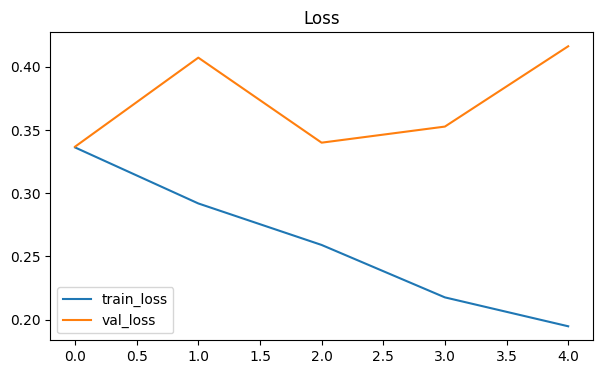

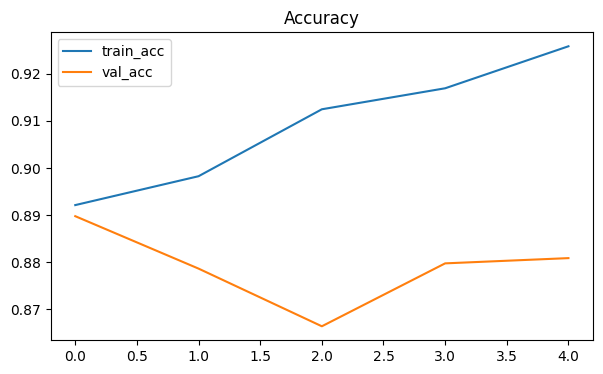

In [ ]:
plt.figure()
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss")
plt.show()

plt.figure()
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Accuracy")
plt.show()


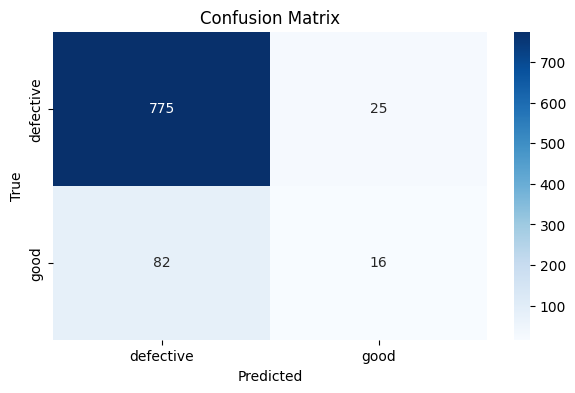

              precision    recall  f1-score   support

   defective       0.90      0.97      0.94       800
        good       0.39      0.16      0.23        98

    accuracy                           0.88       898
   macro avg       0.65      0.57      0.58       898
weighted avg       0.85      0.88      0.86       898



In [ ]:
# Collect true & predicted labels
y_true = []
for _, labels in test_ds:
    y_true.extend(np.argmax(labels.numpy(), axis=1))
y_true = np.array(y_true)

y_pred = []
for imgs, _ in test_ds:
    preds = model.predict(imgs, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred, labels=[0,1])  # ensure 2 classes order
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names
)
plt.title("Confusion Matrix")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))


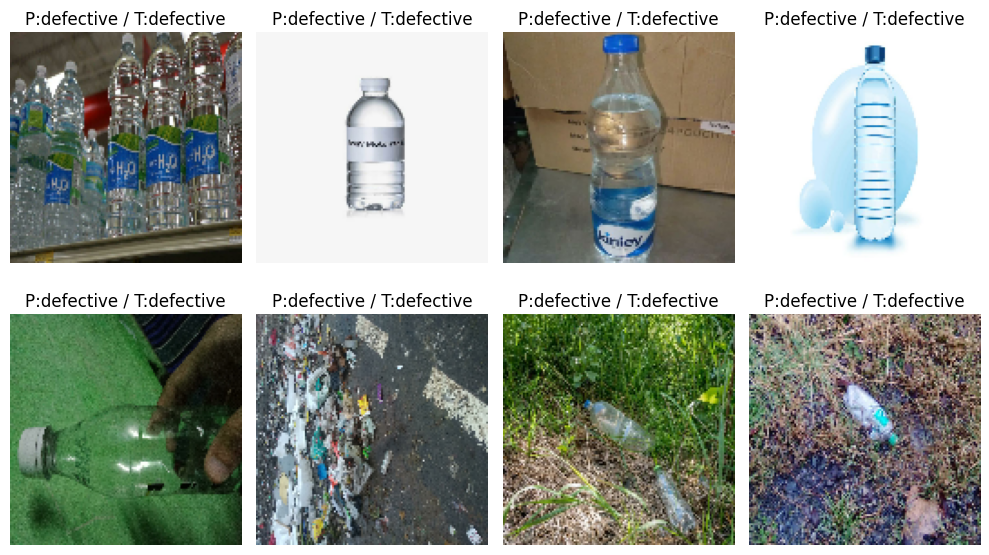

In [ ]:
plt.figure(figsize=(10,6))
n_show = 8

for imgs, labels in test_ds.take(1):
    preds = model.predict(imgs, verbose=0)
    for i in range(n_show):
        ax = plt.subplot(2,4,i+1)
        plt.imshow(imgs[i].numpy().astype("uint8"))
        p = class_names[np.argmax(preds[i])]
        t = class_names[np.argmax(labels[i].numpy())]
        plt.title(f"P:{p} / T:{t}")
        plt.axis("off")

plt.tight_layout()
plt.show()


defect_type
generic_defect    3999
Name: count, dtype: int64


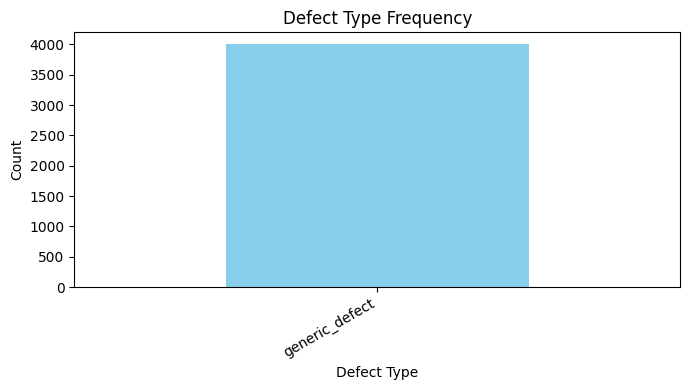

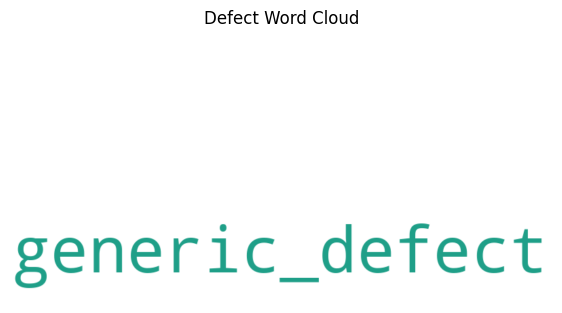

In [ ]:
labels_csv = "/content/milk_bottle_defects/labels.csv"

if os.path.exists(labels_csv):
    df = pd.read_csv(labels_csv)
    df['defect_type'] = df['defect_type'].fillna("")

    freq = df[df['class']=="defective"]['defect_type'].value_counts()
    print(freq)

    # Bar chart
    freq.plot(kind='bar', color='skyblue')
    plt.title("Defect Type Frequency")
    plt.xlabel("Defect Type")
    plt.ylabel("Count")
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

    # Word cloud
    text = " ".join(df[df['class']=="defective"]['defect_type'].tolist()) or "no_defects"
    wc = WordCloud(width=800, height=400, background_color="white").generate(text)
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title("Defect Word Cloud")
    plt.show()
else:
    print(" labels.csv not found — skipping NLP add-on.")


In [ ]:
save_path = "/content/milk_bottle_cnn.keras"
model.save(save_path)
print("Model saved as:", save_path)


Model saved as: /content/milk_bottle_cnn.keras


In [ ]:
import os
os.listdir("/content")


['.config',
 'drive',
 'milk_bottle_defects',
 'bottle_defects_raw',
 'good_bottles_raw',
 'milk_bottle_cnn.keras',
 'sample_data']

In [ ]:
from tensorflow import keras

model = keras.models.load_model("/content/milk_bottle_cnn.keras")

class_names = ["defective", "good"]

print("✅ Model loaded successfully")


✅ Model loaded successfully


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

def predict_and_show(img_path, title=""):
    img = image.load_img(img_path, target_size=(128,128))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array, verbose=0)[0]
    pred_idx = np.argmax(pred)
    pred_label = class_names[pred_idx]
    confidence = float(pred[pred_idx])

    plt.imshow(img)
    plt.title(f"{title}\nPrediction: {pred_label} ({confidence:.2f})")
    plt.axis("off")
    plt.show()

    print("Predicted class:", pred_label)
    print("Confidence:", confidence)


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving gettyimages-1334118474-640_adpp.mp4 to gettyimages-1334118474-640_adpp.mp4


In [ ]:
import os
os.listdir()

['.config',
 'drive',
 'milk_bottle_defects',
 'bottle_defects_raw',
 'good_bottles_raw',
 'gettyimages-1334118474-640_adpp.mp4',
 'milk_bottle_cnn.keras',
 'sample_data']

In [ ]:
import cv2
import os

video_path = "369223124.webm"
output_dir = "frames"

os.makedirs(output_dir, exist_ok=True)

cap = cv2.VideoCapture(video_path)

frame_count = 0
save_every_n_frames = 5   # 🔴 change to 1 if you want ALL frames

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    if frame_count % save_every_n_frames == 0:
        frame_name = f"{output_dir}/frame_{frame_count:05d}.jpg"
        cv2.imwrite(frame_name, frame)

    frame_count += 1

cap.release()
print(f"Done! Extracted frames: {len(os.listdir(output_dir))}")


Done! Extracted frames: 0


In [ ]:
import os

print(os.listdir("/content"))

['.config', 'drive', 'frames', 'milk_bottle_defects', 'bottle_defects_raw', 'good_bottles_raw', 'gettyimages-1334118474-640_adpp.mp4', 'milk_bottle_cnn.keras', 'sample_data']


In [ ]:
import cv2
import os

# ---- Paths ----
video_path = "/content/gettyimages-1334118474-640_adpp .mp4"
output_dir = "/content/frames"

# ---- Create output folder ----
os.makedirs(output_dir, exist_ok=True)

# ---- Open video ----
cap = cv2.VideoCapture(video_path)

# ---- Check if video opened ----
if not cap.isOpened():
    print("❌ ERROR: Video not opened. Check path or format.")
else:
    print("✅ Video opened successfully")

frame_count = 0
saved_count = 0
save_every_n_frames = 5   # change to 1 for ALL frames

while True:
    ret, frame = cap.read()
    if not ret:
        break

    if frame_count % save_every_n_frames == 0:
        frame_name = f"{output_dir}/frame_{frame_count:05d}.jpg"
        cv2.imwrite(frame_name, frame)
        saved_count += 1

    frame_count += 1

cap.release()

print(f"✅ Total frames read: {frame_count}")
print(f"✅ Frames saved: {saved_count}")


❌ ERROR: Video not opened. Check path or format.
✅ Total frames read: 0
✅ Frames saved: 0


In [ ]:
import cv2
import numpy as np
import os
from tensorflow import keras

# Load trained model
model = keras.models.load_model("/content/milk_bottle_cnn.keras")
class_names = ["defective", "good"]

frames_dir = "/content/frames"
output_dir = "/content/predicted_frames"
os.makedirs(output_dir, exist_ok=True)

for fname in sorted(os.listdir(frames_dir)):
    img_path = os.path.join(frames_dir, fname)

    # Load image
    img = cv2.imread(img_path)
    img_resized = cv2.resize(img, (128,128))
    img_norm = img_resized / 255.0
    img_input = np.expand_dims(img_norm, axis=0)

    # Prediction
    pred = model.predict(img_input, verbose=0)[0]
    pred_idx = np.argmax(pred)
    label = class_names[pred_idx]
    confidence = np.max(pred)

    # Draw result on frame
    text = f"{label.upper()} ({confidence:.2f})"
    color = (0,255,0) if label=="good" else (0,0,255)
    cv2.putText(img, text, (10,40),
                cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)

    # Save output frame
    cv2.imwrite(os.path.join(output_dir, fname), img)

print("✅ Frame classification completed")


✅ Frame classification completed


In [ ]:
import cv2
import os

frames_path = "/content/predicted_frames"
output_video = "/content/conveyor_output.mp4"

frames = sorted(os.listdir(frames_path))
first_frame = cv2.imread(os.path.join(frames_path, frames[0]))
height, width, _ = first_frame.shape

video = cv2.VideoWriter(
    output_video,
    cv2.VideoWriter_fourcc(*'mp4v'),
    10,
    (width, height)
)

for frame in frames:
    img = cv2.imread(os.path.join(frames_path, frame))
    video.write(img)

video.release()
print("🎥 Conveyor belt demo video created:", output_video)


IndexError: list index out of range

In [ ]:
from tensorflow import keras
import os

MODEL_PATH = "/content/milk_bottle_cnn.keras"   # change if different
print("Model exists?", os.path.exists(MODEL_PATH))

model = keras.models.load_model(MODEL_PATH)
class_names = ["defective", "good"]  # MUST match training folder order
print("✅ Model loaded")


In [ ]:
import cv2
import numpy as np
import os

video_path = "/content/gettyimages-1334118474-640_adpp.mp4"
out_path   = "/content/conveyor_output.mp4"

cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise RuntimeError("❌ Video not opened. Check path.")

fps = cap.get(cv2.CAP_PROP_FPS)
w   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(out_path, fourcc, fps if fps>0 else 25, (w,h))

def preprocess(frame):
    img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (128,128))
    img = img.astype(np.float32) / 255.0
    img = np.expand_dims(img, axis=0)
    return img

frame_i = 0
save_every = 1  # keep 1 for full video, set 2 or 5 if slow

while True:
    ret, frame = cap.read()
    if not ret:
        break

    if frame_i % save_every == 0:
        x = preprocess(frame)
        pred = model.predict(x, verbose=0)[0]
        idx = int(np.argmax(pred))
        label = class_names[idx]
        conf = float(pred[idx])

        text = f"{label.upper()} ({conf:.2f})"
        color = (0,0,255) if label=="defective" else (0,255,0)  # red/green

        cv2.putText(frame, text, (20,60),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.6, color, 4, cv2.LINE_AA)

    writer.write(frame)
    frame_i += 1

cap.release()
writer.release()

print("✅ Saved:", out_path)


In [ ]:
from google.colab import files
files.download("/content/conveyor_output.mp4")


In [ ]:
from tensorflow import keras
import numpy as np
import cv2, os

MODEL_PATH = "/content/milk_bottle_cnn.keras"
model = keras.models.load_model(MODEL_PATH)
class_names = ["defective", "good"]  # must match training folder order
print("✅ Model loaded")


In [ ]:
def predict_crop(bgr_crop, img_size=128):
    img = cv2.resize(bgr_crop, (img_size, img_size))
    img = img.astype("float32") / 255.0
    img = np.expand_dims(img, axis=0)
    pred = model.predict(img, verbose=0)[0]
    idx = int(np.argmax(pred))
    return class_names[idx], float(pred[idx])


In [ ]:
def detect_main_object_bbox(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5,5), 0)

    # Edge/threshold
    edges = cv2.Canny(blur, 40, 120)

    # Close gaps
    kernel = np.ones((7,7), np.uint8)
    edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel, iterations=2)

    cnts, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return None

    c = max(cnts, key=cv2.contourArea)
    x,y,w,h = cv2.boundingRect(c)

    # ignore tiny noise
    if w*h < 5000:
        return None
    return (x,y,w,h)


In [ ]:
INPUT_VIDEO = "/content/gettyimages-1334118474-640_adpp.mp4"
OUTPUT_VIDEO = "/content/conveyor_output_ui.mp4"

cap = cv2.VideoCapture(INPUT_VIDEO)
if not cap.isOpened():
    raise RuntimeError("❌ Video not opened. Check INPUT_VIDEO path.")

fps = cap.get(cv2.CAP_PROP_FPS) or 25
W  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H  = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

panel_w = 420
out_w = W + panel_w
out_h = H

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, fps, (out_w, out_h))

bottle_id = 0
wrong_count = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    bottle_id += 1

    # --- detect bbox ---
    bbox = detect_main_object_bbox(frame)

    label = "unknown"
    conf  = 0.0

    if bbox:
        x,y,w,h = bbox
        crop = frame[y:y+h, x:x+w]
        label, conf = predict_crop(crop)

        # draw bbox
        color = (0,255,0) if label=="good" else (0,0,255)
        cv2.rectangle(frame, (x,y), (x+w, y+h), color, 3)

        # top label on frame
        cv2.putText(frame, f"{label.upper()} ({conf:.2f})", (x, max(30,y-10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, color, 3, cv2.LINE_AA)

        if label != "good":
            wrong_count += 1

    # --- build right panel UI ---
    panel = np.full((H, panel_w, 3), 240, dtype=np.uint8)
    cv2.rectangle(panel, (15, 15), (panel_w-15, 210), (0,0,0), 2)

    cv2.putText(panel, f"Bottle ID: {bottle_id}", (30, 60),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0,0,0), 2)

    status_text = "OK" if label=="good" else ("Error" if label=="defective" else "N/A")
    status_color = (0,170,0) if label=="good" else (0,0,255)

    cv2.putText(panel, "Bottle:", (30, 105),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0,0,0), 2)
    cv2.putText(panel, status_text, (150, 105),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, status_color, 2)

    # (Optional placeholders like the sample)
    cv2.putText(panel, "Label:", (30, 145), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0,0,0), 2)
    cv2.putText(panel, "OK", (150, 145), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0,170,0), 2)

    cv2.putText(panel, "Water level:", (30, 185), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0,0,0), 2)
    cv2.putText(panel, "OK", (210, 185), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0,170,0), 2)

    cv2.putText(panel, f"Total wrong bottles: {wrong_count}", (30, H-80),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,0,0), 2)

    # stack frame + panel
    combined = np.hstack([frame, panel])
    writer.write(combined)

cap.release()
writer.release()
print("✅ Saved:", OUTPUT_VIDEO)


In [ ]:
!pip -q install opencv-python-headless tensorflow

import cv2
import numpy as np
from tensorflow import keras


In [ ]:
MODEL_PATH = "/content/milk_bottle_cnn.keras"
model = keras.models.load_model(MODEL_PATH)

# IMPORTANT: this order must match training folder order
# If your training folders were: train/defective , train/good
class_names = ["defective", "good"]

IMG_SIZE = (128, 128)


In [ ]:
class CentroidTracker:
    def __init__(self, max_lost=10, dist_thresh=60):
        self.next_id = 1
        self.objects = {}   # id -> (cx, cy)
        self.lost = {}      # id -> lost_frames
        self.max_lost = max_lost
        self.dist_thresh = dist_thresh

    def update(self, detections):
        # detections: list of (x,y,w,h)
        new_centroids = []
        for (x,y,w,h) in detections:
            cx = x + w//2
            cy = y + h//2
            new_centroids.append((cx, cy))

        if len(self.objects) == 0:
            for c in new_centroids:
                self.objects[self.next_id] = c
                self.lost[self.next_id] = 0
                self.next_id += 1
            return self.objects

        obj_ids = list(self.objects.keys())
        obj_centroids = list(self.objects.values())

        # match existing to new by nearest distance
        used_new = set()
        for oid, oc in zip(obj_ids, obj_centroids):
            best_j = -1
            best_d = 1e9
            for j, nc in enumerate(new_centroids):
                if j in used_new:
                    continue
                d = np.linalg.norm(np.array(oc) - np.array(nc))
                if d < best_d:
                    best_d = d
                    best_j = j

            if best_j != -1 and best_d < self.dist_thresh:
                self.objects[oid] = new_centroids[best_j]
                self.lost[oid] = 0
                used_new.add(best_j)
            else:
                self.lost[oid] += 1

        # remove lost
        for oid in list(self.lost.keys()):
            if self.lost[oid] > self.max_lost:
                self.lost.pop(oid, None)
                self.objects.pop(oid, None)

        # add new detections not used
        for j, nc in enumerate(new_centroids):
            if j not in used_new:
                self.objects[self.next_id] = nc
                self.lost[self.next_id] = 0
                self.next_id += 1

        return self.objects


In [ ]:
def cnn_predict_bottle(frame, bbox):
    x,y,w,h = bbox
    roi = frame[y:y+h, x:x+w]
    if roi.size == 0:
        return "good", 0.0

    roi_rgb = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)
    roi_resized = cv2.resize(roi_rgb, IMG_SIZE)
    x_in = roi_resized.astype(np.float32) / 255.0
    x_in = np.expand_dims(x_in, axis=0)

    pred = model.predict(x_in, verbose=0)[0]  # [p_defective, p_good] OR 2-softmax
    idx = int(np.argmax(pred))
    label = class_names[idx]
    conf = float(pred[idx])
    return label, conf


In [ ]:
def check_label_ok(roi):
    # label region = middle band. If edges/text exist => OK
    h, w = roi.shape[:2]
    y1, y2 = int(h*0.45), int(h*0.75)
    band = roi[y1:y2, :]
    gray = cv2.cvtColor(band, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 50, 150)
    edge_ratio = edges.mean() / 255.0
    return edge_ratio > 0.02  # tune

def check_water_level_ok(roi):
    # crude check: look for horizontal intensity change in lower half
    h, w = roi.shape[:2]
    lower = roi[int(h*0.55):, :]
    gray = cv2.cvtColor(lower, cv2.COLOR_BGR2GRAY)
    # vertical gradient summed horizontally
    grad = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    score = np.mean(np.abs(grad))
    return score > 3.0  # tune


In [ ]:
VIDEO_PATH = "/content/gettyimages-1334118474-640_adpp.mp4"
OUT_PATH   = "/content/conveyor_output_ui.mp4"

cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise RuntimeError("Video not opened. Check VIDEO_PATH.")

fps = cap.get(cv2.CAP_PROP_FPS) or 25
W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

ui_w = 420
outW, outH = W + ui_w, H

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(OUT_PATH, fourcc, fps, (outW, outH))

# Background subtractor works well when camera is fixed
bg = cv2.createBackgroundSubtractorMOG2(history=300, varThreshold=25, detectShadows=False)

tracker = CentroidTracker(max_lost=12, dist_thresh=80)

# store per-ID decision so we count only once
id_status = {}  # id -> {"label":..., "conf":..., "counted":bool, "label_ok":bool, "water_ok":bool}
wrong_count = 0

frame_idx = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break
    frame_idx += 1

    # --- DETECT bottles via motion+contours ---
    fg = bg.apply(frame)
    fg = cv2.medianBlur(fg, 5)
    _, fg = cv2.threshold(fg, 180, 255, cv2.THRESH_BINARY)
    fg = cv2.morphologyEx(fg, cv2.MORPH_OPEN, np.ones((5,5), np.uint8), iterations=2)
    fg = cv2.dilate(fg, np.ones((5,5), np.uint8), iterations=2)

    contours, _ = cv2.findContours(fg, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    dets = []
    for c in contours:
        x,y,w,h = cv2.boundingRect(c)
        area = w*h
        # tune these for your video
        if area < 2500 or h < 60 or w < 25:
            continue
        # keep inside frame
        x = max(0, x); y = max(0, y)
        dets.append((x,y,w,h))

    objects = tracker.update(dets)

    # choose one “active” bottle to show in UI (nearest to center)
    active_id = None
    if len(objects) > 0:
        cx0 = W//2
        best = 1e9
        for oid, (cx,cy) in objects.items():
            d = abs(cx - cx0)
            if d < best:
                best = d
                active_id = oid

    # --- draw detections + classify (only first time per ID) ---
    for (x,y,w,h) in dets:
        cx, cy = x + w//2, y + h//2

        # find matching id by nearest centroid
        best_id = None
        best_d = 1e9
        for oid, (ocx, ocy) in objects.items():
            d = np.linalg.norm(np.array([cx,cy]) - np.array([ocx,ocy]))
            if d < best_d:
                best_d = d
                best_id = oid

        if best_id is None:
            continue

        if best_id not in id_status:
            # classify ONCE when ID first appears
            pred_label, conf = cnn_predict_bottle(frame, (x,y,w,h))

            roi = frame[y:y+h, x:x+w]
            label_ok = check_label_ok(roi) if roi.size else True
            water_ok = check_water_level_ok(roi) if roi.size else True

            id_status[best_id] = {
                "label": pred_label,
                "conf": conf,
                "counted": False,
                "label_ok": label_ok,
                "water_ok": water_ok
            }

            if pred_label == "defective" and not id_status[best_id]["counted"]:
                wrong_count += 1
                id_status[best_id]["counted"] = True

        s = id_status[best_id]
        pred_label = s["label"]
        conf = s["conf"]

        # color: RED defective, BLUE good
        color = (0,0,255) if pred_label == "defective" else (255,0,0)

        cv2.rectangle(frame, (x,y), (x+w, y+h), color, 3)
        cv2.putText(frame, f"ID {best_id} {pred_label} ({conf:.2f})",
                    (x, max(25, y-10)), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

    # --- build UI panel ---
    panel = np.ones((H, ui_w, 3), dtype=np.uint8) * 245
    cv2.rectangle(panel, (20,20), (ui_w-20, 220), (0,0,0), 2)

    if active_id is not None and active_id in id_status:
        s = id_status[active_id]
        bottle_state = "Error" if s["label"] == "defective" else "OK"
        label_state  = "OK" if s["label_ok"] else "Missing"
        water_state  = "OK" if s["water_ok"] else "Low"

        cv2.putText(panel, f"Bottle ID: {active_id}", (40,70), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0,0,0), 2)

        cv2.putText(panel, f"Bottle: {bottle_state}", (40,115), cv2.FONT_HERSHEY_SIMPLEX, 0.9,
                    (0,0,255) if bottle_state=="Error" else (0,150,0), 2)

        cv2.putText(panel, f"Label: {label_state}", (40,155), cv2.FONT_HERSHEY_SIMPLEX, 0.9,
                    (0,150,0) if label_state=="OK" else (0,0,255), 2)

        cv2.putText(panel, f"Water level: {water_state}", (40,195), cv2.FONT_HERSHEY_SIMPLEX, 0.9,
                    (0,150,0) if water_state=="OK" else (0,0,255), 2)
    else:
        cv2.putText(panel, "Bottle ID: -", (40,70), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0,0,0), 2)
        cv2.putText(panel, "Bottle: -", (40,115), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0,0,0), 2)
        cv2.putText(panel, "Label: -", (40,155), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0,0,0), 2)
        cv2.putText(panel, "Water level: -", (40,195), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0,0,0), 2)

    cv2.putText(panel, f"Total wrong bottles: {wrong_count}", (40, H-60),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0,0,0), 2)

    # --- combine frame + panel ---
    combined = np.hstack([frame, panel])
    writer.write(combined)

cap.release()
writer.release()

print("✅ Saved:", OUT_PATH)


In [ ]:
!pip -q install ultralytics opencv-python

import cv2
import numpy as np
from ultralytics import YOLO
from tensorflow import keras


In [ ]:
cnn = keras.models.load_model("/content/milk_bottle_cnn.keras")
class_names = ["defective", "good"]  # change order if your training order was different


In [ ]:
print("CNN loaded. Classes:", class_names)


In [ ]:
yolo = YOLO("yolov8n.pt")  # small & fast


In [ ]:
def classify_bottle_crop(bgr_crop):
    # resize to your CNN input
    img = cv2.resize(bgr_crop, (128, 128))
    img = img.astype(np.float32) / 255.0
    img = np.expand_dims(img, axis=0)

    pred = cnn.predict(img, verbose=0)[0]  # shape (2,)
    idx = int(np.argmax(pred))
    label = class_names[idx]
    conf = float(pred[idx])
    return label, conf


In [ ]:
video_path = "/content/gettyimages-1334118474-640_adpp.mp4"
out_path   = "/content/conveyor_output_ui.mp4"

cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS) or 25
W   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

panel_w = 520
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(out_path, fourcc, fps, (W + panel_w, H))

# tracking + counting
seen_ids = set()
defective_ids = set()
bottle_id_counter = 0

# Use YOLO tracking (ByteTrack)
# NOTE: we call yolo.track per frame using persist=True
# and classes=[39] ensures only bottle detections
tracker_cfg = "bytetrack.yaml"

frame_idx = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break
    frame_idx += 1

    # --- YOLO track ---
    results = yolo.track(
        source=frame,
        persist=True,
        tracker=tracker_cfg,
        classes=[39],     # bottle only
        conf=0.35,        # increase if too many false detections
        iou=0.5,
        verbose=False
    )

    r = results[0]
    bottles_in_frame = 0

    if r.boxes is not None and len(r.boxes) > 0:
        boxes = r.boxes.xyxy.cpu().numpy().astype(int)

        # track ids may be None sometimes
        ids = None
        if r.boxes.id is not None:
            ids = r.boxes.id.cpu().numpy().astype(int)

        for i, (x1, y1, x2, y2) in enumerate(boxes):
            # basic safety clamp
            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(W-1, x2), min(H-1, y2)
            if x2 <= x1 or y2 <= y1:
                continue

            # If tracker gives ID use it, else create a fallback ID
            if ids is not None:
                bid = int(ids[i])
            else:
                bottle_id_counter += 1
                bid = bottle_id_counter

            seen_ids.add(bid)
            bottles_in_frame += 1

            crop = frame[y1:y2, x1:x2]
            pred_label, pred_conf = classify_bottle_crop(crop)

            if pred_label == "defective":
                defective_ids.add(bid)
                color = (0, 0, 255)   # red (BGR)
            else:
                color = (255, 0, 0)   # blue (BGR)

            # Draw bbox + text
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
            cv2.putText(frame, f"ID {bid} {pred_label} ({pred_conf:.2f})",
                        (x1, max(25, y1-10)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    # --- Right-side UI panel ---
    panel = np.full((H, panel_w, 3), 245, dtype=np.uint8)
    cv2.rectangle(panel, (20, 40), (panel_w-20, 260), (0,0,0), 2)

    # Main ID shown = last seen bottle id (roughly)
    show_id = max(seen_ids) if len(seen_ids) else 0
    bottle_status = "Error" if show_id in defective_ids else "OK"
    bottle_color  = (0,0,255) if bottle_status=="Error" else (0,150,0)

    cv2.putText(panel, f"Bottle ID: {show_id}", (40, 90),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0,0,0), 2)
    cv2.putText(panel, "Bottle:", (40, 140),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0,0,0), 2)
    cv2.putText(panel, bottle_status, (190, 140),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, bottle_color, 2)

    # Placeholder for label/water-level (see note below)
    cv2.putText(panel, "Label:  OK", (40, 190),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0,150,0), 2)
    cv2.putText(panel, "Water level: OK", (40, 240),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0,150,0), 2)

    cv2.putText(panel, f"Total wrong bottles: {len(defective_ids)}",
                (60, H-60), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0,0,0), 2)

    combined = np.hstack([frame, panel])
    out.write(combined)

cap.release()
out.release()
print("✅ Saved:", out_path)


In [ ]:
from google.colab import files
files.download("/content/conveyor_output_ui.mp4")


In [ ]:
import cv2

def draw_status_panel(frame,
                      bottle_id: int,
                      is_defective: bool,
                      has_label: bool,
                      water_ok: bool,
                      total_wrong: int):
    """
    Draws the right white panel with dynamic text.
    Call this once per frame.
    """

    h, w = frame.shape[:2]

    # --- panel position ---
    panel_x1 = int(w * 0.55)
    panel_y1 = int(h * 0.05)
    panel_x2 = int(w * 0.98)
    panel_y2 = int(h * 0.75)

    # draw white rectangle
    cv2.rectangle(frame, (panel_x1, panel_y1),
                  (panel_x2, panel_y2),
                  (255, 255, 255), thickness=-1)   # filled
    cv2.rectangle(frame, (panel_x1, panel_y1),
                  (panel_x2, panel_y2),
                  (0, 0, 0), thickness=3)          # border

    font  = cv2.FONT_HERSHEY_SIMPLEX
    thick = 2

    # ---- bottle status line ----
    bottle_text  = "Error" if is_defective else "OK"
    bottle_color = (0, 0, 255) if is_defective else (0, 180, 0)

    # ---- label line ----
    if has_label:
        label_text  = "OK"
        label_color = (0, 180, 0)
    else:
        label_text  = "No label"
        label_color = (0, 0, 255)

    # ---- water level line ----
    if water_ok:
        water_text  = "OK"
        water_color = (0, 180, 0)
    else:
        water_text  = "Low / error"
        water_color = (0, 0, 255)

    # --- draw text ---
    x = panel_x1 + 25
    y = panel_y1 + 60
    dy = 60

    cv2.putText(frame, f"Bottle ID: {bottle_id}",
                (x, y), font, 1.1, (0, 0, 0), thick, cv2.LINE_AA)

    cv2.putText(frame, "Bottle:",
                (x, y + dy), font, 1.1, (0, 0, 0), thick, cv2.LINE_AA)
    cv2.putText(frame, bottle_text,
                (x + 190, y + dy), font, 1.1, bottle_color, thick, cv2.LINE_AA)

    cv2.putText(frame, "Label:",
                (x, y + 2*dy), font, 1.1, (0, 0, 0), thick, cv2.LINE_AA)
    cv2.putText(frame, label_text,
                (x + 190, y + 2*dy), font, 1.1, label_color, thick, cv2.LINE_AA)

    cv2.putText(frame, "Water level:",
                (x, y + 3*dy), font, 1.1, (0, 0, 0), thick, cv2.LINE_AA)
    cv2.putText(frame, water_text,
                (x + 260, y + 3*dy), font, 1.1, water_color, thick, cv2.LINE_AA)

    # ---- total wrong bottles (bottom) ----
    bottom_y = panel_y2 - 40
    cv2.putText(frame,
                f"Total wrong bottles: {total_wrong}",
                (x, bottom_y),
                font, 1.1, (0, 0, 0), thick, cv2.LINE_AA)

    return frame


In [ ]:
import cv2
import numpy as np

def draw_status_panel(frame,
                      bottle_id,
                      is_defective,
                      has_label,
                      water_ok,
                      total_wrong):
    """
    Draws the right-side white panel with text that depends on the flags.
    """

    h, w, _ = frame.shape
    panel_w = int(w * 0.35)          # 35% of width for panel
    x0 = w - panel_w                 # left x of panel

    # White background
    cv2.rectangle(frame, (x0, 0), (w-1, h-1), (255, 255, 255), -1)
    # Black border
    cv2.rectangle(frame, (x0, 0), (w-1, h-1), (0, 0, 0), 3)

    # ---- Decide texts based on flags ----
    bottle_text = "Error" if is_defective else "OK"
    bottle_color = (0, 0, 255) if is_defective else (0, 160, 0)

    label_text  = "NO LABEL" if not has_label else "OK"
    label_color = (0, 0, 255) if not has_label else (0, 160, 0)

    water_text  = "LOW" if not water_ok else "OK"
    water_color = (0, 0, 255) if not water_ok else (0, 160, 0)

    # ---- Write text ----
    x_txt = x0 + 40
    y = 100
    dy = 70
    font = cv2.FONT_HERSHEY_SIMPLEX

    cv2.putText(frame, f"Bottle ID: {bottle_id}", (x_txt, y),
                font, 1.2, (0, 0, 0), 3)

    y += dy
    cv2.putText(frame, "Bottle:", (x_txt, y), font, 1.2, (0, 0, 0), 3)
    cv2.putText(frame, bottle_text, (x_txt + 200, y),
                font, 1.2, bottle_color, 3)

    y += dy
    cv2.putText(frame, "Label:", (x_txt, y), font, 1.2, (0, 0, 0), 3)
    cv2.putText(frame, label_text, (x_txt + 200, y),
                font, 1.2, label_color, 3)

    y += dy
    cv2.putText(frame, "Water level:", (x_txt, y), font, 1.2, (0, 0, 0), 3)
    cv2.putText(frame, water_text, (x_txt + 280, y),
                font, 1.2, water_color, 3)

    # Total wrong bottles at the bottom
    y_bottom = h - 80
    cv2.putText(frame, f"Total wrong bottles: {total_wrong}",
                (x_txt, y_bottom), font, 1.2, (0, 0, 0), 3)

    return frame


In [ ]:
import numpy as np
import cv2
from tensorflow import keras

# Load trained model once
model = keras.models.load_model("/content/milk_bottle_cnn.keras")
class_names = ["defective", "good"]   # MUST match training order

cap = cv2.VideoCapture("/content/sample_data/conveyor_output.mp4")

current_bottle_id = 0
total_wrong_bottles = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # =====================================
    # 1) FIND BOTTLES  (you already do this)
    # =====================================
    bottle_boxes = []   # list of (x, y, w, h)

    # ---- EXAMPLE dummy detector: split horizontally ----
    # (If you already have boxes, just delete this block.)
    h, w, _ = frame.shape
    n = 10
    bw = w // (n + 2)
    y_top = int(h * 0.35)
    y_bottom = int(h * 0.95)
    for i in range(1, n+1):
        x = i * bw
        bottle_boxes.append((x, y_top, bw-5, y_bottom - y_top))
    # -----------------------------------

    # =====================================
    # 2) RUN CNN + DRAW BOXES
    # =====================================
    for (x, y, bw, bh) in bottle_boxes:
        roi = frame[y:y+bh, x:x+bw]
        if roi.size == 0:
            continue

        # Resize, normalize like training
        img = cv2.resize(roi, (128, 128))
        img = img.astype("float32") / 255.0
        img = np.expand_dims(img, axis=0)

        # CNN prediction
        pred = model.predict(img, verbose=0)[0]
        pred_idx = int(np.argmax(pred))
        pred_conf = float(pred[pred_idx])
        pred_class = class_names[pred_idx]      # "good" or "defective"

        # ---- NOW THERE IS NO NameError: pred_class exists HERE ----

        # Logic for statuses (you can explain this to prof)
        is_defective = (pred_class == "defective")

        # very simple assumptions for the UI:
        # - if defective → assume NO LABEL (missing label)
        # - water level is always OK in this dataset
        has_label = not is_defective   # defective → "NO LABEL"
        water_ok = True

        # box color
        color = (0, 0, 255) if is_defective else (255, 0, 0)

        # draw bounding box
        cv2.rectangle(frame, (x, y), (x + bw, y + bh), color, 2)

        # ID + prediction on top of bottle
        txt = f"ID {current_bottle_id} {pred_class} ({pred_conf:.2f})"
        cv2.putText(frame, txt, (x, max(30, y-10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

        # update counters
        if is_defective:
            total_wrong_bottles += 1

        # draw right-side status panel for THIS bottle
        frame = draw_status_panel(
            frame,
            bottle_id=current_bottle_id,
            is_defective=is_defective,
            has_label=has_label,
            water_ok=water_ok,
            total_wrong=total_wrong_bottles
        )

        current_bottle_id += 1

    # show frame (for demo in class you can also write to video)
    cv2.imshow("Conveyor QA", frame)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


In [ ]:
import cv2
import os

video_path = "/content/sample_data/conveyor_output_ui.mp4"  # or wherever you want

# Get width, height, fps from input video
w  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h  = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS) or 25   # fallback

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(video_path, fourcc, fps, (w, h))


In [ ]:
cap.release()
out.release()
cv2.destroyAllWindows()

print("✅ Done. Saved UI video to:", video_path)


In [ ]:
from google.colab.patches import cv2_imshow


In [ ]:
import shutil

# Folder where frames are stored
frames_dir = "/content/frames"   # change if your folder name is different

# Output zip file
zip_path = "/content/frames_all.zip"

shutil.make_archive(zip_path.replace(".zip",""), 'zip', frames_dir)

print("✅ Frames zipped successfully")


In [ ]:
from google.colab import files
files.download("/content/frames_all.zip")
